# Canadian Labour Market Data Cleaning & Preprocessing
Auric Intelligence (Team 2) - Week 12 WIL Project

**Team Members:**
- Aarjeyan Shrestha
- Karun Kumar Atreya
- Sudip Chaudhary
- Saugat Babu Bhattarai

# Canadian Labour Market Dataset - Feature Descriptions

| Feature | Data Type | Description | Purpose |
|---------|-----------|-------------|---------|
| **Date_Period** | String/Date | Time period in YYYY-MM format (e.g., "2023-01") representing monthly data points from January 2019 to June 2024 | Enables time-series analysis and tracking of labour market trends over the COVID-19 period and recovery |
| **Province_Territory** | String | Canadian province or territory name (13 total: 10 provinces + 3 territories) | Geographic segmentation for provincial comparison and regional policy impact analysis |
| **Economic_Region** | String | Major Census Metropolitan Area (CMA) or rural region within each province (e.g., "Toronto CMA", "Rural ON") | Sub-provincial analysis to identify local economic patterns and urban vs rural differences |
| **Unemployment_Rate** | Float | Percentage of labour force that is unemployed (0-30% range) | Key indicator of labour market health and ESDC program effectiveness |
| **Job_Vacancy_Rate** | Float | Percentage of total job positions that are unfilled (0-15% range) | Measures labour demand and skill shortages, indicates tight vs loose labour markets |
| **Employment_Growth_Rate** | Float | Year-over-year percentage change in total employment (-25% to +20% range) | Tracks job creation/loss trends and economic recovery patterns |
| **Total_Labour_Force** | Integer | Total number of people aged 15+ who are employed or actively seeking employment | Denominator for calculating unemployment rates and labour market participation |
| **Total_Employed** | Integer | Total number of people currently employed in the region | Core employment metric for measuring job market strength |
| **Total_Unemployed** | Integer | Total number of people actively seeking work but currently without employment | Numerator for unemployment rate calculations and program targeting |
| **Total_Job_Positions** | Integer | Total number of job positions available in the economy (filled + vacant) | Measures overall labour demand and economic capacity |
| **Vacant_Job_Positions** | Integer | Number of unfilled job positions actively being recruited for | Indicates labour shortages and skills mismatches |
| **Primary_Industry_Sector** | String | Dominant economic sector in the region (Services, Manufacturing, Resources, Technology, etc.) | Sectoral analysis to understand which industries drive regional employment |
| **Survey_Response_Rate** | Float | Percentage response rate for labour force surveys (60-95% range) | Data quality indicator for statistical reliability assessment |
| **Data_Quality_Flag** | String | Quality indicator for the data record (Good, Revised, Preliminary, Estimated, Poor, Unknown) | Helps analysts assess data reliability and flag potentially problematic records |
| **Data_Source** | String | Source of the data record (Statistics Canada, LFS, JVWS, etc.) | Provides data lineage and helps with source-specific validation |
| **Record_ID** | String/Integer | Unique identifier for each data record | Technical field for data management and duplicate detection |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load the raw messy dataset
df_raw = pd.read_csv('comprehensive_canadian_labour_market_2019_2024.csv')

# Display basic information about the dataset
print(f"Dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print("\nFirst 5 rows:")
df_raw.head()

Dataset shape: (2064, 16)
Columns: ['Date_Period', 'Province_Territory', 'Economic_Region', 'Unemployment_Rate', 'Job_Vacancy_Rate', 'Employment_Growth_Rate', 'Total_Labour_Force', 'Total_Employed', 'Total_Unemployed', 'Total_Job_Positions', 'Vacant_Job_Positions', 'Primary_Industry_Sector', 'Survey_Response_Rate', 'Data_Quality_Flag', 'Data_Source', 'Record_ID']

First 5 rows:


,Date_Period,Province_Territory,Economic_Region,Unemployment_Rate,Job_Vacancy_Rate,Employment_Growth_Rate,Total_Labour_Force,Total_Employed,Total_Unemployed,Total_Job_Positions,Vacant_Job_Positions,Primary_Industry_Sector,Survey_Response_Rate,Data_Quality_Flag,Data_Source,Record_ID
0,2019-01,Newfoundland and Labrador,St. John's CMA,12.7,3.5,2.4,NaN,109467,15995,NaN,3903,Construction,NaN,Preliminary,LFS,1
1,2019-01,Newfoundland and Labrador,Rural NL,NaN,2.1,2.8,62814,54886,7928,58315,1234,Manuf.,78.6,Revised,LFS,2
2,2019-01,Prince Edward Island,Charlottetown CMA,8.3,2.4,1.8,58955,54088,4867,56872,1344,Mixed,76.9,NaN,JVWS,3
3,2019-01,Prince Edward Island,Rural PEI,8.5,2.9,1.9,62954,57630,5324,59264,1697,SERVICES,NaN,NaN,NaN,4
4,2019-01,Nova Scotia,Halifax CMA,7.8,2.9,2.7,259180,239046,20134,251202,7315,NaN,NaN,Estimated,LFS,5


### Initial Data Inspection

In [ ]:
print("\n=== DATA TYPES AND MISSING VALUES ===")
print(df_raw.info())


=== DATA TYPES AND MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2064 entries, 0 to 2063
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Date_Period              2051 non-null   object
 1   Province_Territory       2055 non-null   object
 2   Economic_Region          2048 non-null   object
 3   Unemployment_Rate        1934 non-null   object
 4   Job_Vacancy_Rate         1937 non-null   object
 5   Employment_Growth_Rate   1970 non-null   object
 6   Total_Labour_Force       1981 non-null   object
 7   Total_Employed           1992 non-null   object
 8   Total_Unemployed         1975 non-null   object
 9   Total_Job_Positions      1973 non-null   object
 10  Vacant_Job_Positions     1929 non-null   object
 11  Primary_Industry_Sector  1933 non-null   object
 12  Survey_Response_Rate     1598 non-null   object
 13  Data_Quality_Flag        1487 non-null   object
 14  D

In [5]:
print("\nMissing values per column:")
missing_values = df_raw.isnull().sum()
missing_percentage = (missing_values / len(df_raw)) * 100
missing_summary = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
})
print(missing_summary[missing_summary['Missing_Count'] > 0])


Missing values per column:
                         Missing_Count  Missing_Percentage
Date_Period                         13            0.629845
Province_Territory                   9            0.436047
Economic_Region                     16            0.775194
Unemployment_Rate                  130            6.298450
Job_Vacancy_Rate                   127            6.153101
Employment_Growth_Rate              94            4.554264
Total_Labour_Force                  83            4.021318
Total_Employed                      72            3.488372
Total_Unemployed                    89            4.312016
Total_Job_Positions                 91            4.408915
Vacant_Job_Positions               135            6.540698
Primary_Industry_Sector            131            6.346899
Survey_Response_Rate               466           22.577519
Data_Quality_Flag                  577           27.955426
Data_Source                        428           20.736434


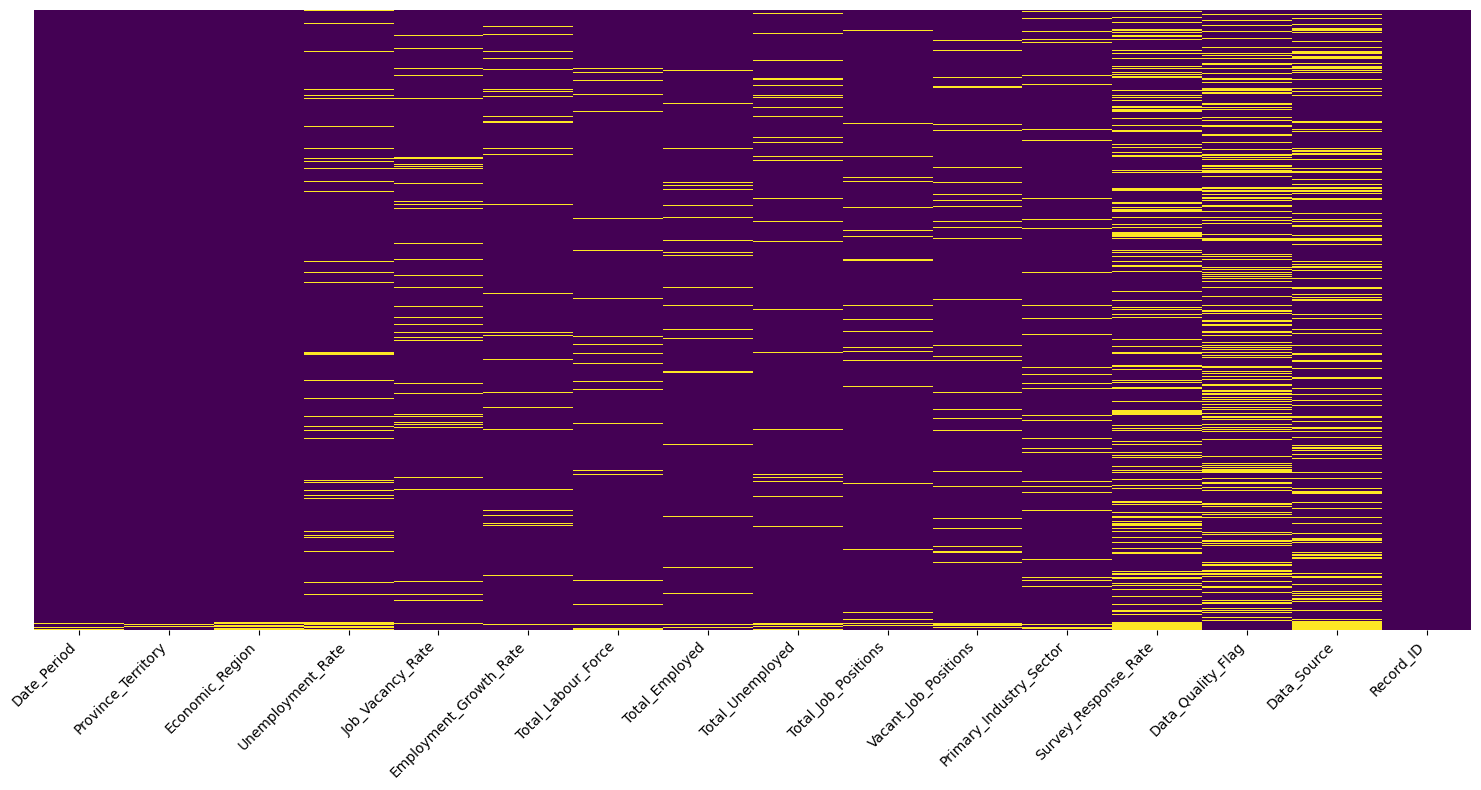

In [6]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_raw.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Categorical Data Inconsistency

In [7]:
# Examine unique values in categorical columns to identify inconsistencies
print("\n=== CATEGORICAL DATA INCONSISTENCIES ===")

print("Unique Province/Territory values:")
print(f"Count: {df_raw['Province_Territory'].nunique()}")
print("Sample values:", df_raw['Province_Territory'].value_counts().head(10))

print("\nUnique Economic Region values:")
print(f"Count: {df_raw['Economic_Region'].nunique()}")
print("Sample values:", df_raw['Economic_Region'].value_counts().head(10))

print("\nUnique Date Period formats:")
print("Sample values:", df_raw['Date_Period'].value_counts().head(10))


=== CATEGORICAL DATA INCONSISTENCIES ===
Unique Province/Territory values:
Count: 91
Sample values: Province_Territory
Ontario                      172
Saskatchewan                 145
Alberta                      142
Quebec                       140
British Columbia             131
New Brunswick                127
Prince Edward Island         117
Newfoundland and Labrador    101
Nova Scotia                   99
Manitoba                      94
Name: count, dtype: int64

Unique Economic Region values:
Count: 109
Sample values: Economic_Region
Rural SK     71
Rural BC     69
Rural NL     69
Rural ON     68
Rural AB     68
Rural QC     67
Rural PEI    67
Rural NS     67
Rural MB     67
Rural NB     67
Name: count, dtype: int64

Unique Date Period formats:
Sample values: Date_Period
2022-07    30
2021-01    30
2019-09    29
2024-01    29
2023-08    29
2020-08    29
2023-01    29
2019-05    29
2024-04    28
2023-09    28
Name: count, dtype: int64


### Standardise Geographic names

In [8]:
# Create a copy for cleaning
df_clean = df_raw.copy()

# Define mapping dictionaries for standardization
province_mapping = {
    'NEWFOUNDLAND AND LABRADOR': 'Newfoundland and Labrador',
    'Nfld. and Lab.': 'Newfoundland and Labrador',
    'NL': 'Newfoundland and Labrador',
    'P.E.I.': 'Prince Edward Island',
    'PEI': 'Prince Edward Island',
    'Prince Edward Isl.': 'Prince Edward Island',
    'NOVA SCOTIA': 'Nova Scotia',
    'N.S.': 'Nova Scotia',
    'NEW BRUNSWICK': 'New Brunswick',
    'N.B.': 'New Brunswick',
    'QUEBEC': 'Quebec',
    'Québec': 'Quebec',
    'QC': 'Quebec',
    'ONTARIO': 'Ontario',
    'Ont.': 'Ontario',
    'ON': 'Ontario',
    'MANITOBA': 'Manitoba',
    'Man.': 'Manitoba',
    'MB': 'Manitoba',
    'SASKATCHEWAN': 'Saskatchewan',
    'Sask.': 'Saskatchewan',
    'SK': 'Saskatchewan',
    'ALBERTA': 'Alberta',
    'Alta.': 'Alberta',
    'AB': 'Alberta',
    'BRITISH COLUMBIA': 'British Columbia',
    'B.C.': 'British Columbia',
    'BC': 'British Columbia',
    'YUKON': 'Yukon',
    'Yukon Territory': 'Yukon',
    'Y.T.': 'Yukon',
    'NORTHWEST TERRITORIES': 'Northwest Territories',
    'N.W.T.': 'Northwest Territories',
    'NWT': 'Northwest Territories',
    'NUNAVUT': 'Nunavut',
    'Nunavut Territory': 'Nunavut'
}

In [9]:
# Function to clean province names
def clean_province_name(province):
    if pd.isna(province):
        return None
    
    # Remove extra whitespace
    province = str(province).strip()
    
    # Apply mapping if exists
    if province in province_mapping:
        return province_mapping[province]
    
    # Return as-is if already clean
    return province

# Apply province cleaning
df_clean['Province_Territory'] = df_clean['Province_Territory'].apply(clean_province_name)

print("=== PROVINCE NAME STANDARDIZATION ===")
print("Unique provinces after cleaning:")
print(df_clean['Province_Territory'].value_counts())

=== PROVINCE NAME STANDARDIZATION ===
Unique provinces after cleaning:
Province_Territory
Ontario                      283
Alberta                      216
Saskatchewan                 207
New Brunswick                202
Quebec                       200
British Columbia             197
Manitoba                     147
Prince Edward Island         134
Nova Scotia                  134
Newfoundland and Labrador    124
Northwest Territories         67
Nunavut                       67
Yukon                         61
International                  7
Unknown                        6
Foreign                        3
Name: count, dtype: int64


We're creating a mapping dictionary to convert all province name variations to standard names.

This ensures consistency across our dataset - "Ontario", "ONTARIO", and "Ont." all become "Ontario".

This step is crucial for grouping and filtering data by province in our visualizations.

In [10]:
# Clean Economic Region names
region_mapping = {
    'ST. JOHNS CMA': "St. John's CMA",
    'St Johns Metropolitan Area': "St. John's CMA",
    'HALIFAX CMA': 'Halifax CMA',
    'Halifax Metro': 'Halifax CMA',
    'Halifax Regional Municipality': 'Halifax CMA',
    'MONCTON CMA': 'Moncton CMA',
    'Greater Moncton': 'Moncton CMA',
    'Moncton Metropolitan Area': 'Moncton CMA',
    'MONTREAL CMA': 'Montreal CMA',
    'Montréal CMA': 'Montreal CMA',
    'Greater Montreal': 'Montreal CMA',
    'Montreal Metro': 'Montreal CMA',
    'QUEBEC CITY CMA': 'Quebec City CMA',
    'Québec CMA': 'Quebec City CMA',
    'Quebec Metro': 'Quebec City CMA',
    'OTTAWA-GATINEAU CMA': 'Ottawa-Gatineau CMA',
    'Ottawa CMA': 'Ottawa-Gatineau CMA',
    'National Capital Region': 'Ottawa-Gatineau CMA',
    'TORONTO CMA': 'Toronto CMA',
    'Greater Toronto Area': 'Toronto CMA',
    'GTA': 'Toronto CMA',
    'Toronto Metro': 'Toronto CMA',
    'HAMILTON CMA': 'Hamilton CMA',
    'Greater Hamilton': 'Hamilton CMA',
    'Hamilton-Burlington': 'Hamilton CMA',
    'WINNIPEG CMA': 'Winnipeg CMA',
    'Greater Winnipeg': 'Winnipeg CMA',
    'Winnipeg Metro': 'Winnipeg CMA',
    'REGINA CMA': 'Regina CMA',
    'Greater Regina': 'Regina CMA',
    'SASKATOON CMA': 'Saskatoon CMA',
    'Greater Saskatoon': 'Saskatoon CMA',
    'CALGARY CMA': 'Calgary CMA',
    'Greater Calgary': 'Calgary CMA',
    'Calgary Metro': 'Calgary CMA',
    'EDMONTON CMA': 'Edmonton CMA',
    'Greater Edmonton': 'Edmonton CMA',
    'Edmonton Metro': 'Edmonton CMA',
    'VANCOUVER CMA': 'Vancouver CMA',
    'Greater Vancouver': 'Vancouver CMA',
    'Vancouver Metro': 'Vancouver CMA',
    'Lower Mainland': 'Vancouver CMA',
    'VICTORIA CMA': 'Victoria CMA',
    'Greater Victoria': 'Victoria CMA',
    'Victoria Metro': 'Victoria CMA'
}


In [11]:
def clean_region_name(region):
    if pd.isna(region):
        return None
    
    region = str(region).strip()
    
    if region in region_mapping:
        return region_mapping[region]
    
    return region

df_clean['Economic_Region'] = df_clean['Economic_Region'].apply(clean_region_name)

print("\n=== ECONOMIC REGION STANDARDIZATION ===")
print("Unique regions after cleaning:")
print(df_clean['Economic_Region'].value_counts().head(15))


=== ECONOMIC REGION STANDARDIZATION ===
Unique regions after cleaning:
Economic_Region
Rural SK        71
Rural BC        69
Rural NL        69
Rural ON        68
Rural AB        68
Rural MB        67
Rural NB        67
Rural QC        67
Rural NS        67
Rural PEI       67
Victoria CMA    66
Calgary CMA     66
Halifax CMA     64
Toronto CMA     63
Moncton CMA     61
Name: count, dtype: int64


Similar to provinces, we're standardizing economic region names to ensure consistency.

This prevents "Toronto CMA", "Greater Toronto Area", and "GTA" from being treated as different regions.

### Standardize Date Format

In [12]:
def parse_messy_date(date_str):
    """
    Parse various date formats and return standardized YYYY-MM format
    """
    if pd.isna(date_str):
        return None
    
    date_str = str(date_str).strip()
    
    # Skip obviously invalid dates
    invalid_dates = ['', 'N/A', 'Invalid', 'Unknown', '2025-13', 'Jan-20']
    if date_str in invalid_dates:
        return None
    
    try:
        # Try different date formats
        date_formats = [
            '%Y-%m',      # 2023-01
            '%Y/%m',      # 2023/01
            '%m/%Y',      # 01/2023
            '%b %Y',      # Jan 2023
            '%B %Y',      # January 2023
            '%Y-%m-%d',   # 2023-01-01
            '%m-%d-%Y'    # 01-01-2023
        ]
        
        for fmt in date_formats:
            try:
                parsed_date = datetime.strptime(date_str, fmt)
                return parsed_date.strftime('%Y-%m')
            except ValueError:
                continue
        
        # If no format works, return None
        return None
        
    except:
        return None

In [13]:
df_clean['Date_Period_Clean'] = df_clean['Date_Period'].apply(parse_messy_date)

print("=== DATE FORMAT STANDARDIZATION ===")
print("Original date formats (sample):")
print(df_clean[['Date_Period', 'Date_Period_Clean']].head(10))

print(f"\nSuccessfully parsed: {df_clean['Date_Period_Clean'].notna().sum()} dates")
print(f"Failed to parse: {df_clean['Date_Period_Clean'].isna().sum()} dates")

# Replace original date column
df_clean['Date_Period'] = df_clean['Date_Period_Clean']
df_clean.drop('Date_Period_Clean', axis=1, inplace=True)

=== DATE FORMAT STANDARDIZATION ===
Original date formats (sample):
  Date_Period Date_Period_Clean
0     2019-01           2019-01
1     2019-01           2019-01
2     2019-01           2019-01
3     2019-01           2019-01
4     2019-01           2019-01
5     2019-01           2019-01
6     2019-01           2019-01
7  2019-01-01           2019-01
8     2019-01           2019-01
9     2019-01           2019-01

Successfully parsed: 2039 dates
Failed to parse: 25 dates


### HANDLE PERCENTAGE AND NUMERIC DATA ISSUES

In [14]:
def clean_percentage_column(series):
    """
    Clean percentage columns that might have strings with %, wrong scaling, or other issues
    """
    cleaned = series.copy()
    
    for i, value in enumerate(cleaned):
        if pd.isna(value):
            continue
            
        # Convert to string for processing
        str_value = str(value).strip()
        
        # Skip invalid values
        if str_value in ['', 'N/A', 'High', 'Low', 'Many', 'Few', 'Unknown']:
            cleaned.iloc[i] = None
            continue
        
        try:
            # Handle percentage strings (remove % and convert)
            if '%' in str_value:
                numeric_value = float(str_value.replace('%', ''))
                cleaned.iloc[i] = numeric_value
            else:
                numeric_value = float(str_value)
                # Fix common scaling errors (values over 100 likely already in percentage form)
                if numeric_value > 100:
                    cleaned.iloc[i] = numeric_value / 100
                else:
                    cleaned.iloc[i] = numeric_value
                    
        except (ValueError, TypeError):
            cleaned.iloc[i] = None
    
    return pd.to_numeric(cleaned, errors='coerce')

In [15]:
# Clean percentage columns
print("=== CLEANING PERCENTAGE COLUMNS ===")

# Before cleaning
print("Unemployment Rate - Before cleaning (sample values):")
print(df_clean['Unemployment_Rate'].head(10))

df_clean['Unemployment_Rate'] = clean_percentage_column(df_clean['Unemployment_Rate'])
df_clean['Job_Vacancy_Rate'] = clean_percentage_column(df_clean['Job_Vacancy_Rate'])
df_clean['Employment_Growth_Rate'] = clean_percentage_column(df_clean['Employment_Growth_Rate'])

print("\nUnemployment Rate - After cleaning (sample values):")
print(df_clean['Unemployment_Rate'].head(10))

=== CLEANING PERCENTAGE COLUMNS ===
Unemployment Rate - Before cleaning (sample values):
0    12.7
1     NaN
2     8.3
3     8.5
4     7.8
5     7.7
6     8.5
7     8.6
8     8.7
9     4.9
Name: Unemployment_Rate, dtype: object

Unemployment Rate - After cleaning (sample values):
0    12.7
1     NaN
2     8.3
3     8.5
4     7.8
5     7.7
6     8.5
7     8.6
8     8.7
9     4.9
Name: Unemployment_Rate, dtype: float64


We're handling common issues with percentage data:
1. String percentages ("5.2%") converted to numeric (5.2)
2. Wrong scaling (520 instead of 5.2) corrected by dividing by 100
3. Invalid text values ("High", "Low") converted to null

Also the dtype has been changed

In [16]:
def clean_numeric_column(series, allow_negative=False):
    """
    Clean numeric columns, handling various data entry errors
    """
    cleaned = series.copy()
    
    for i, value in enumerate(cleaned):
        if pd.isna(value):
            continue
        
        str_value = str(value).strip()
        
        # Skip invalid values
        if str_value in ['', 'N/A', 'Unknown', 'Large', 'Many', 'Some', 'Few']:
            cleaned.iloc[i] = None
            continue
        
        try:
            numeric_value = float(str_value)
            
            # Handle negative values
            if not allow_negative and numeric_value < 0:
                # Convert negative to positive (likely data entry error)
                cleaned.iloc[i] = abs(numeric_value)
            else:
                cleaned.iloc[i] = numeric_value
                
        except (ValueError, TypeError):
            cleaned.iloc[i] = None
    
    return pd.to_numeric(cleaned, errors='coerce')

# Clean numeric columns
print("\n=== CLEANING NUMERIC COLUMNS ===")

df_clean['Total_Labour_Force'] = clean_numeric_column(df_clean['Total_Labour_Force'])
df_clean['Total_Employed'] = clean_numeric_column(df_clean['Total_Employed'])
df_clean['Total_Unemployed'] = clean_numeric_column(df_clean['Total_Unemployed'])
df_clean['Total_Job_Positions'] = clean_numeric_column(df_clean['Total_Job_Positions'])
df_clean['Vacant_Job_Positions'] = clean_numeric_column(df_clean['Vacant_Job_Positions'])

# Employment growth can be negative, so allow negative values
df_clean['Employment_Growth_Rate'] = clean_numeric_column(df_clean['Employment_Growth_Rate'], allow_negative=True)

print("Numeric columns cleaned successfully")



=== CLEANING NUMERIC COLUMNS ===
Numeric columns cleaned successfully


### Handle Outliers and Impossible Values

In [17]:
# Define reasonable ranges for validation
def validate_and_fix_outliers(df):
    """
    Identify and fix outliers and impossible values
    """
    df_validated = df.copy()
    
    # Unemployment rate should be between 0% and 30%
    mask = (df_validated['Unemployment_Rate'] > 30) | (df_validated['Unemployment_Rate'] < 0)
    outlier_count = mask.sum()
    df_validated.loc[mask, 'Unemployment_Rate'] = None
    print(f"Fixed {outlier_count} unemployment rate outliers")
    
    # Job vacancy rate should be between 0% and 15%
    mask = (df_validated['Job_Vacancy_Rate'] > 15) | (df_validated['Job_Vacancy_Rate'] < 0)
    outlier_count = mask.sum()
    df_validated.loc[mask, 'Job_Vacancy_Rate'] = None
    print(f"Fixed {outlier_count} job vacancy rate outliers")
    
    # Employment growth rate should be between -25% and 20%
    mask = (df_validated['Employment_Growth_Rate'] > 20) | (df_validated['Employment_Growth_Rate'] < -25)
    outlier_count = mask.sum()
    df_validated.loc[mask, 'Employment_Growth_Rate'] = None
    print(f"Fixed {outlier_count} employment growth rate outliers")
    
    # Labour force numbers should be reasonable (> 1000, < 10 million)
    mask = (df_validated['Total_Labour_Force'] > 10000000) | (df_validated['Total_Labour_Force'] < 1000)
    outlier_count = mask.sum()
    df_validated.loc[mask, 'Total_Labour_Force'] = None
    print(f"Fixed {outlier_count} labour force outliers")
    
    return df_validated

print("=== OUTLIER DETECTION AND CORRECTION ===")
df_clean = validate_and_fix_outliers(df_clean)

=== OUTLIER DETECTION AND CORRECTION ===
Fixed 15 unemployment rate outliers
Fixed 29 job vacancy rate outliers
Fixed 36 employment growth rate outliers
Fixed 6 labour force outliers


We're identifying values that are statistically impossible or unrealistic:
1. Unemployment rates over 30% or below 0%
2. Job vacancy rates over 15% or below 0%
3. Employment growth outside reasonable bounds (-25% to +20%)
4. Labour force numbers that are too large or small to be realistic

### Remove Duplicates

In [18]:
# Identify duplicates based on key columns
key_columns = ['Date_Period', 'Province_Territory', 'Economic_Region']

print("=== DUPLICATE RECORD REMOVAL ===")
print(f"Total records before duplicate removal: {len(df_clean)}")

# Find duplicates
duplicates = df_clean.duplicated(subset=key_columns, keep='first')
print(f"Duplicate records found: {duplicates.sum()}")

# Remove duplicates
df_clean = df_clean[~duplicates].copy()
print(f"Records after duplicate removal: {len(df_clean)}")

=== DUPLICATE RECORD REMOVAL ===
Total records before duplicate removal: 2064
Duplicate records found: 77
Records after duplicate removal: 1987


### Removing Completely Invalid Rows
1. Rows with missing or invalid province names
2. Rows with missing dates
3. Rows where ALL key economic indicators are missing

In [19]:
def remove_invalid_rows(df):
    """
    Remove rows that have too many missing values or are completely invalid
    """
    # Remove rows where province is missing or invalid
    invalid_provinces = ['', 'Unknown', 'International', 'Foreign', None]
    mask_province = ~df['Province_Territory'].isin(invalid_provinces) & df['Province_Territory'].notna()
    
    # Remove rows where date is missing
    mask_date = df['Date_Period'].notna()
    
    # Remove rows where ALL key indicators are missing
    key_indicators = ['Unemployment_Rate', 'Job_Vacancy_Rate', 'Employment_Growth_Rate']
    mask_indicators = df[key_indicators].notna().any(axis=1)
    
    # Combine all conditions
    valid_rows = mask_province & mask_date & mask_indicators
    
    return df[valid_rows].copy()

print("=== REMOVING INVALID ROWS ===")
print(f"Records before invalid row removal: {len(df_clean)}")

df_clean = remove_invalid_rows(df_clean)

print(f"Records after invalid row removal: {len(df_clean)}")

=== REMOVING INVALID ROWS ===
Records before invalid row removal: 1987
Records after invalid row removal: 1980


### Standardize Categorical Variables

In [20]:
# Clean industry sector column
def clean_industry_sector(sector):
    if pd.isna(sector):
        return 'Unknown'
    
    sector = str(sector).strip()
    
    # Mapping for industry standardization
    industry_mapping = {
        'SERVICES': 'Services',
        'services': 'Services',
        'Service Sector': 'Services',
        'Tech': 'Technology',
        'Manuf.': 'Manufacturing',
        'Natural Resources': 'Resources',
        'N/A': 'Unknown',
        '': 'Unknown',
        'Mixed': 'Mixed',
        'Other': 'Unknown'
    }
    
    if sector in industry_mapping:
        return industry_mapping[sector]
    
    return sector

df_clean['Primary_Industry_Sector'] = df_clean['Primary_Industry_Sector'].apply(clean_industry_sector)

print("=== INDUSTRY SECTOR STANDARDIZATION ===")
print("Industry sectors after cleaning:")
print(df_clean['Primary_Industry_Sector'].value_counts())


=== INDUSTRY SECTOR STANDARDIZATION ===
Industry sectors after cleaning:
Primary_Industry_Sector
Services         411
Manufacturing    258
Technology       240
Unknown          162
Healthcare       134
Government       134
Construction     129
Resources        121
Education        121
Agriculture      119
Finance          119
Mixed             32
Name: count, dtype: int64


In [21]:
# Clean data quality flags
def clean_quality_flag(flag):
    if pd.isna(flag):
        return 'Unknown'
    
    flag = str(flag).strip()
    
    if flag in ['', 'ERROR - EXCLUDE']:
        return 'Poor'
    elif flag in ['Duplicate']:
        return 'Poor'
    elif flag in ['Good', 'Revised', 'Preliminary', 'Estimated']:
        return flag
    else:
        return 'Unknown'

df_clean['Data_Quality_Flag'] = df_clean['Data_Quality_Flag'].apply(clean_quality_flag)

print("\nData quality flags after cleaning:")
print(df_clean['Data_Quality_Flag'].value_counts())


Data quality flags after cleaning:
Data_Quality_Flag
Unknown        856
Estimated      292
Preliminary    283
Good           283
Revised        266
Name: count, dtype: int64


We're standardizing categorical variables to ensure consistency:
1. Industry sectors: Converting variations like "SERVICES", "services" to "Services"
2. Quality flags: Standardizing quality indicators for data reliability assessment

### Handling Missing Values with Imputation

In [22]:
def impute_missing_values(df):
    """
    Impute missing values using appropriate strategies
    """
    df_imputed = df.copy()
    
    # For numeric columns, use median imputation by province and date
    numeric_cols = ['Unemployment_Rate', 'Job_Vacancy_Rate', 'Employment_Growth_Rate',
                   'Total_Labour_Force', 'Total_Employed', 'Total_Unemployed',
                   'Total_Job_Positions', 'Vacant_Job_Positions']
    
    for col in numeric_cols:
        if col in df_imputed.columns:
            # Group by province and fill missing values with median
            df_imputed[col] = df_imputed.groupby('Province_Territory')[col].transform(
                lambda x: x.fillna(x.median())
            )
            
            # If still missing, fill with overall median
            df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())
    
    return df_imputed

print("=== MISSING VALUE IMPUTATION ===")
print("Missing values before imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

df_clean = impute_missing_values(df_clean)

print("\nMissing values after imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

=== MISSING VALUE IMPUTATION ===
Missing values before imputation:
Unemployment_Rate         125
Job_Vacancy_Rate          139
Employment_Growth_Rate    111
Total_Labour_Force         81
Total_Employed             66
Total_Unemployed           80
Total_Job_Positions        87
Vacant_Job_Positions      120
Survey_Response_Rate      436
Data_Source               395
dtype: int64

Missing values after imputation:
Survey_Response_Rate    436
Data_Source             395
dtype: int64


1. First, we use the median value within the same province (similar economic conditions)
2. If no provincial data exists, we use the overall median

This preserves regional patterns while ensuring no gaps in our analysis.

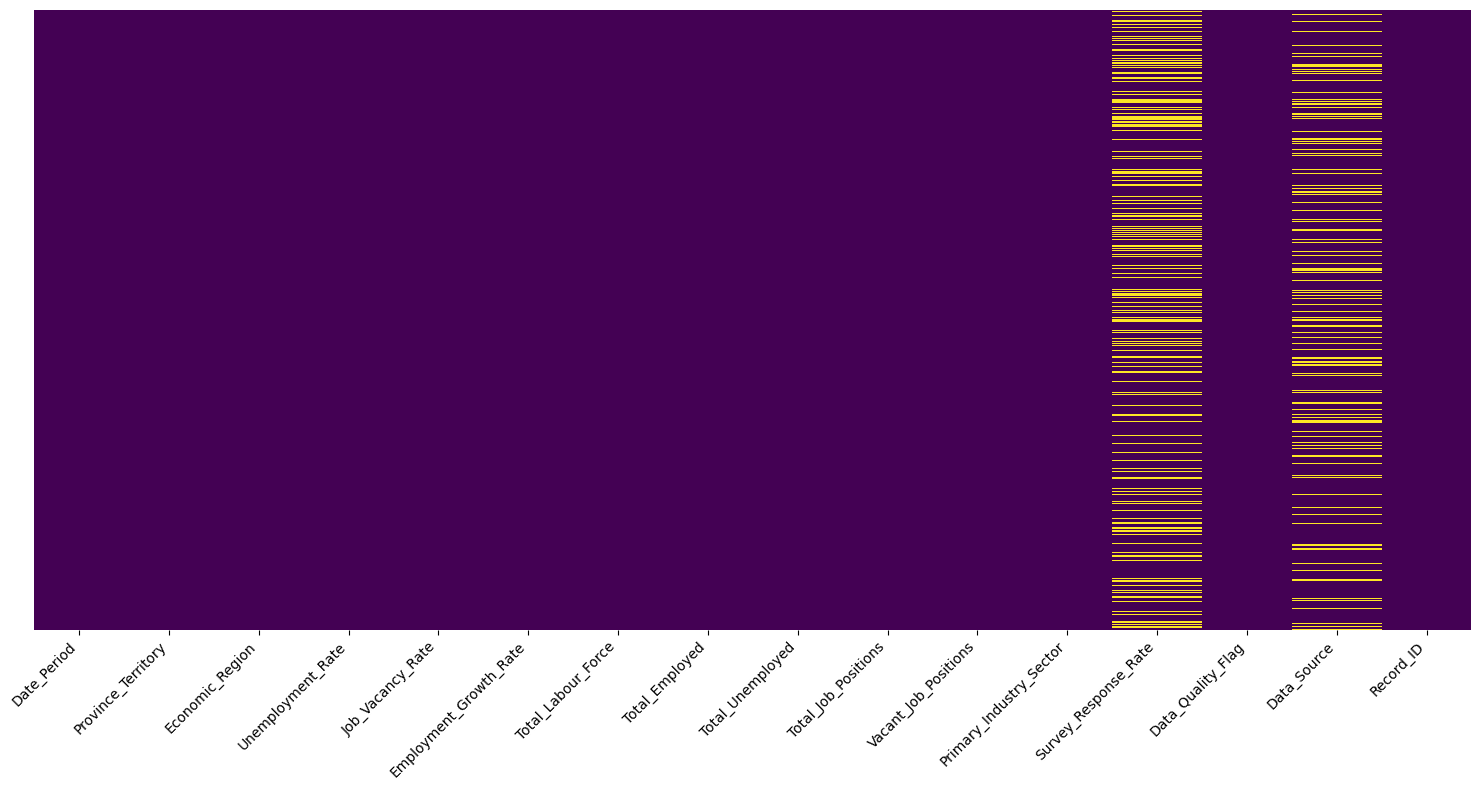

In [23]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_clean.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Explaination on why we are leaving the missing values on the `Survey_Response_Rate` and `Data_Source` columns
We identified these missing values as 'Missing Not At Random' `MNAR` or 'Missing by Design' - they're missing due to data collection system limitations, not random chance or data quality issues. Therefore, imputation would be inappropriate and potentially misleading.

### Final Dataset Validation

In [24]:
print("=== FINAL CLEANED DATASET SUMMARY ===")
print(f"Final dataset shape: {df_clean.shape}")
print(f"Date range: {df_clean['Date_Period'].min()} to {df_clean['Date_Period'].max()}")
print(f"Provinces covered: {df_clean['Province_Territory'].nunique()}")
print(f"Economic regions covered: {df_clean['Economic_Region'].nunique()}")

# Check data quality
print("\n=== DATA QUALITY METRICS ===")
print("Missing values remaining:")
print(df_clean.isnull().sum())

print("\nData types:")
print(df_clean.dtypes)

# Statistical summary of key indicators
print("\n=== KEY INDICATOR STATISTICS ===")
key_stats = df_clean[['Unemployment_Rate', 'Job_Vacancy_Rate', 'Employment_Growth_Rate']].describe()
print(key_stats)


=== FINAL CLEANED DATASET SUMMARY ===
Final dataset shape: (1980, 16)
Date range: 2019-01 to 2024-06
Provinces covered: 13
Economic regions covered: 88

=== DATA QUALITY METRICS ===
Missing values remaining:
Date_Period                  0
Province_Territory           0
Economic_Region              0
Unemployment_Rate            0
Job_Vacancy_Rate             0
Employment_Growth_Rate       0
Total_Labour_Force           0
Total_Employed               0
Total_Unemployed             0
Total_Job_Positions          0
Vacant_Job_Positions         0
Primary_Industry_Sector      0
Survey_Response_Rate       436
Data_Quality_Flag            0
Data_Source                395
Record_ID                    0
dtype: int64

Data types:
Date_Period                 object
Province_Territory          object
Economic_Region             object
Unemployment_Rate          float64
Job_Vacancy_Rate           float64
Employment_Growth_Rate     float64
Total_Labour_Force         float64
Total_Employed           

In [25]:
# Save cleaned dataset
df_clean.to_csv('cleaned_canadian_labour_market_2019_2024.csv', index=False)
print("\n=== DATASET SAVED ===")
print("Cleaned dataset saved as: cleaned_canadian_labour_market_2019_2024.csv")


=== DATASET SAVED ===
Cleaned dataset saved as: cleaned_canadian_labour_market_2019_2024.csv
